# Model 1A — P(P_rot | log_mass, log_σ_mass_lo, log_σ_mass_hi, log_age)

**Variant 1A**: equal training weights, mass + log-scaled asymmetric mass uncertainty as conditioning variables.

Flow x (density variable): `log_prot`  
Conditioning vector: `[log_age_myr, log_mass_msun, log_mass_err_lo, log_mass_err_hi]`  
Loss: logsumexp(W_F · ln p_flow, ln p_out) — no per-star weighting

Training set: 5846 stars (273 with missing age uncertainty dropped for consistency with 1B/1C).  
At inference: fix observed (log_prot, log_mass, log_σ_mass), sweep log_age → posterior P(age | prot, mass, σ_mass).

In [1]:
import sys
sys.path.insert(0, '../..')

import numpy as np
import pandas as pd
import torch
import pickle
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120

from training.constants import LOGA_GRID
from training.data     import load_training
from training.kfold    import run_kfold
from training.infer    import batch_posteriors
from training.metrics  import compute_residuals
from training.report   import training_report, kfold_report, posterior_report, prot_space_report

## 1. Load data

In [2]:
df = load_training('../../cf_data/training_stars.csv', drop_nan_age_err=True)
print(f'Total stars: {len(df)}')
print(f'Clusters: {df["source_paper"].nunique()}')
df[['log_prot', 'log_age_myr', 'log_mass_msun', 'log_mass_err_lo', 'log_mass_err_hi']].describe()

Total stars: 5846
Clusters: 20


,log_prot,log_age_myr,log_mass_msun,log_mass_err_lo,log_mass_err_hi
count,5846.000000,5846.000000,5846.000000,5846.000000,5846.000000
mean,0.276234,2.128005,-0.377199,-1.840845,-1.838215
std,0.571320,0.654343,0.167650,0.246192,0.235414
min,-1.084073,0.176091,-1.008407,-2.624122,-2.617476
25%,-0.152376,1.653213,-0.479014,-1.996526,-1.987311
50%,0.186679,2.123852,-0.332310,-1.864209,-1.856940
75%,0.656998,2.599883,-0.241529,-1.763098,-1.755619
max,2.241546,4.060698,-0.171430,-1.039938,-1.097869


## 2. Define conditioning columns

In [3]:
OBS_COL   = 'log_prot'
COND_COLS = ['log_age_myr', 'log_mass_msun', 'log_mass_err_lo', 'log_mass_err_hi']
N_FOLDS   = 5
STEPS     = 5000

print('Conditioning vector size:', len(COND_COLS))
print('Columns:', COND_COLS)

Conditioning vector size: 4
Columns: ['log_age_myr', 'log_mass_msun', 'log_mass_err_lo', 'log_mass_err_hi']


## 3. K-fold training

In [4]:
results_df, fold_flows, fold_scalers, loss_curves, posteriors_kfold = run_kfold(
    df        = df,
    obs_col   = OBS_COL,
    cond_cols = COND_COLS,
    n_folds   = N_FOLDS,
    steps     = STEPS,
)


=== Fold 1 / 5 ===
step     0  loss 1.177379
step  1000  loss 0.149097
step  2000  loss 0.124440
step  3000  loss 0.114621
step  4000  loss 0.112881
step  5000  loss 0.112099

=== Fold 2 / 5 ===
step     0  loss 1.413218
step  1000  loss 0.148552
step  2000  loss 0.126525
step  3000  loss 0.118519
step  4000  loss 0.117399
step  5000  loss 0.116891

=== Fold 3 / 5 ===
step     0  loss 1.415402
step  1000  loss 0.151387
step  2000  loss 0.131633
step  3000  loss 0.123029
step  4000  loss 0.121977
step  5000  loss 0.121448

=== Fold 4 / 5 ===
step     0  loss 1.417104
step  1000  loss 0.157747
step  2000  loss 0.137762
step  3000  loss 0.130155
step  4000  loss 0.129041
step  5000  loss 0.128505

=== Fold 5 / 5 ===
step     0  loss 1.415627
step  1000  loss 0.154189
step  2000  loss 0.135232
step  3000  loss 0.127117
step  4000  loss 0.125938
step  5000  loss 0.125399


## 4. Training loss

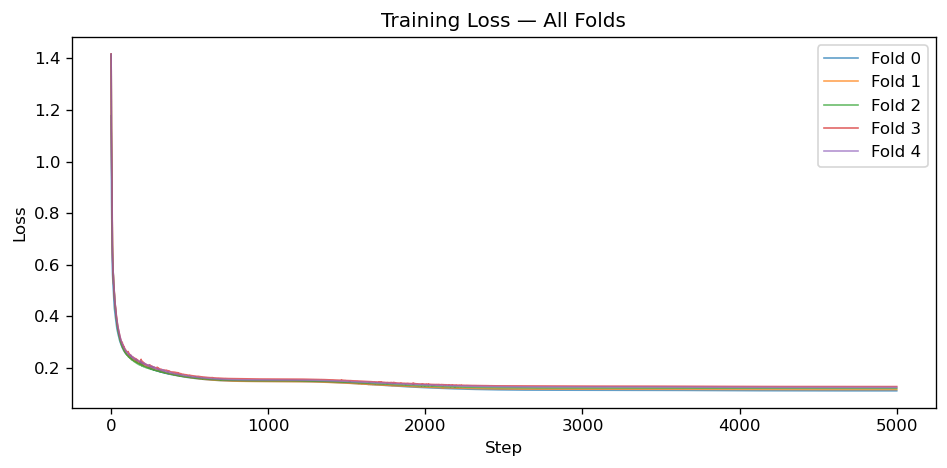

In [5]:
training_report(loss_curves)

## 5. Residual diagnostics

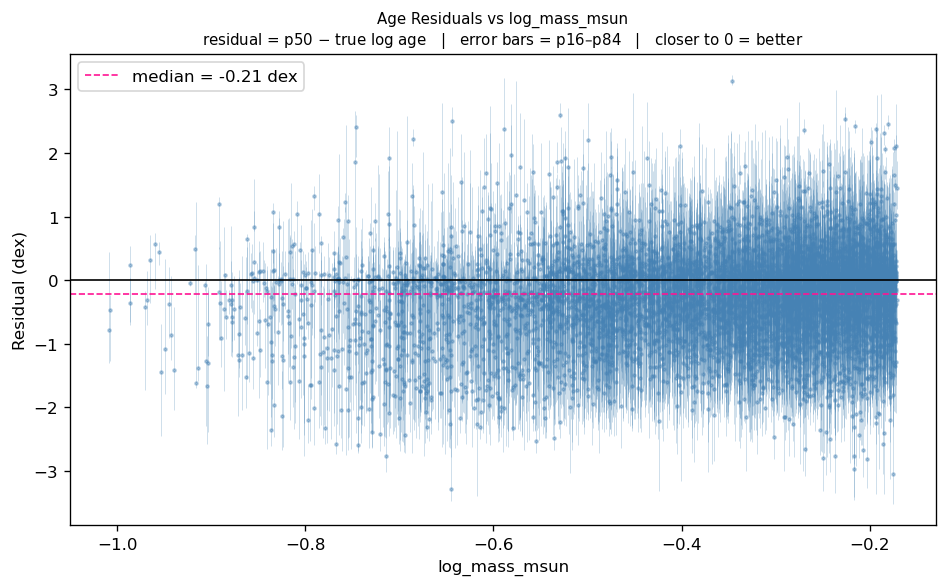

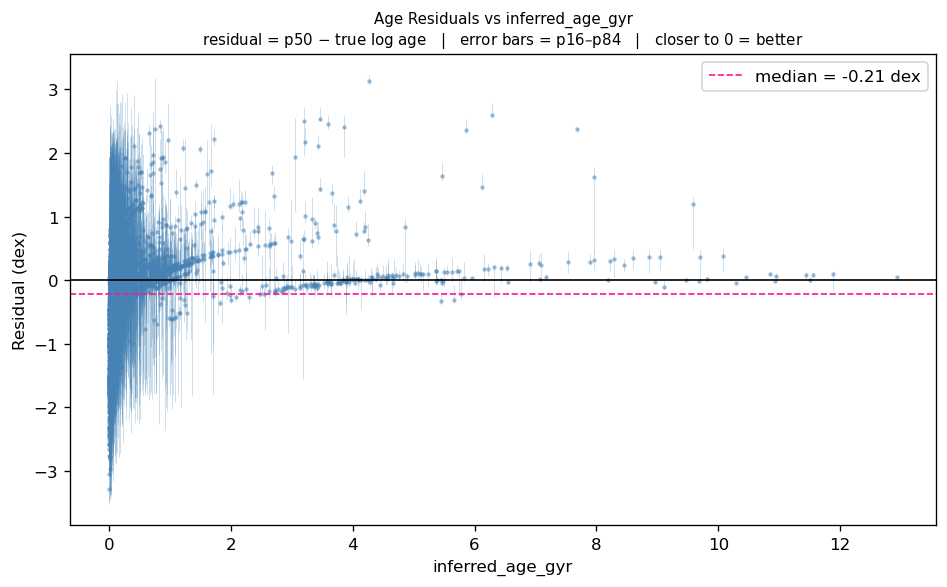

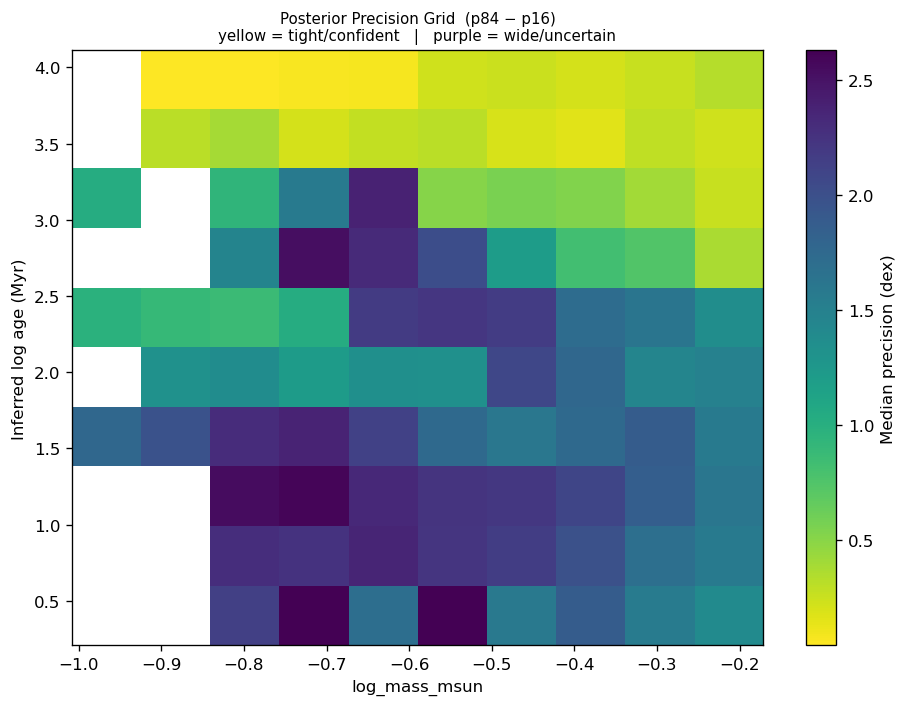

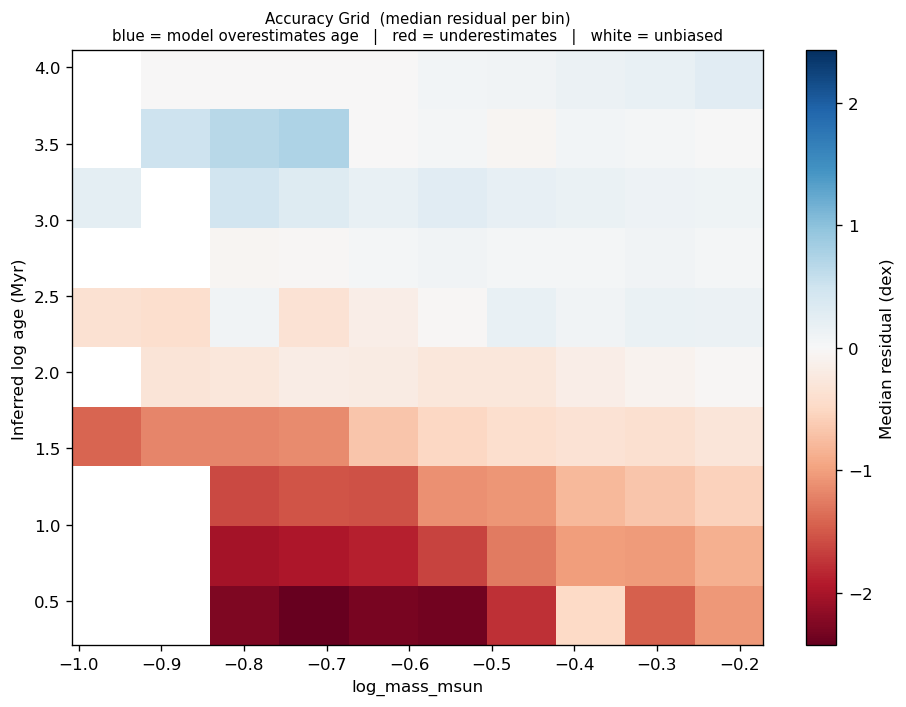

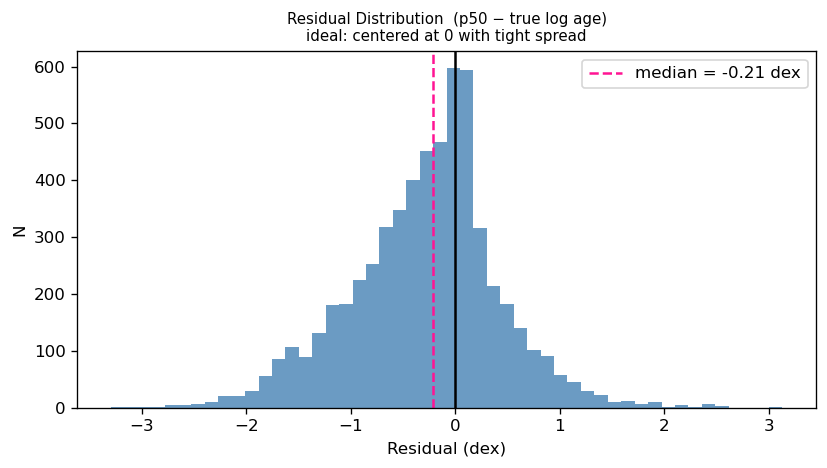

In [14]:
import importlib
import training.plots, training.report
importlib.reload(training.plots)
importlib.reload(training.report)
from training.report import kfold_report


kfold_report(results_df, x_col='log_mass_msun')

## 6. Held-out posteriors (each star evaluated on its val fold)

Posteriors shape: (5846, 1000)


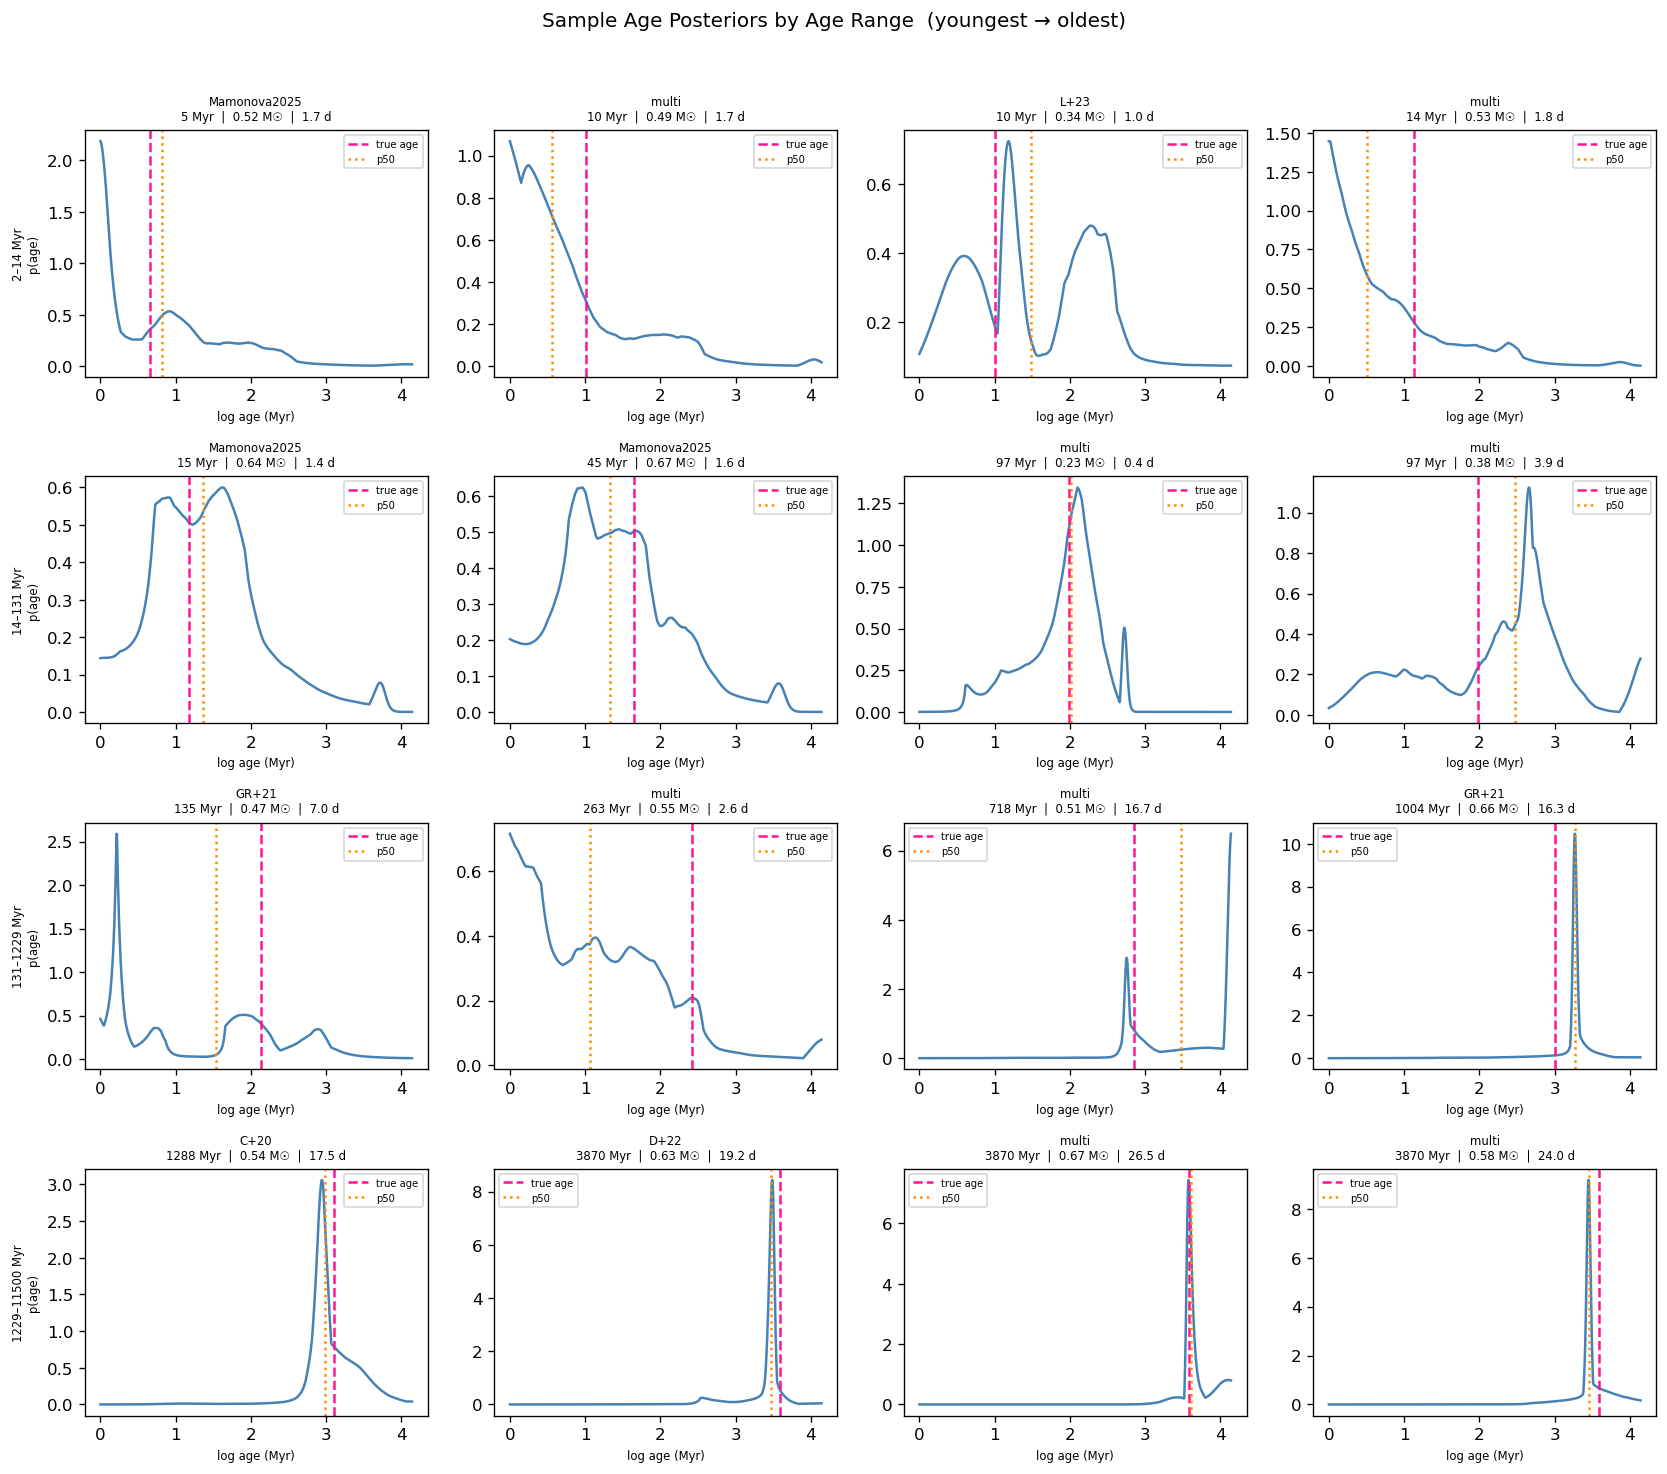

In [18]:
import importlib
import training.plots, training.report
importlib.reload(training.plots)
importlib.reload(training.report)
from training.plots import plot_posteriors_by_age

print('Posteriors shape:', posteriors_kfold.shape)
plot_posteriors_by_age(posteriors_kfold, LOGA_GRID, results_df, n_rows=4, n_cols=4)

## 6b. Posteriors near the fully convective boundary (0.3–0.4 M☉)

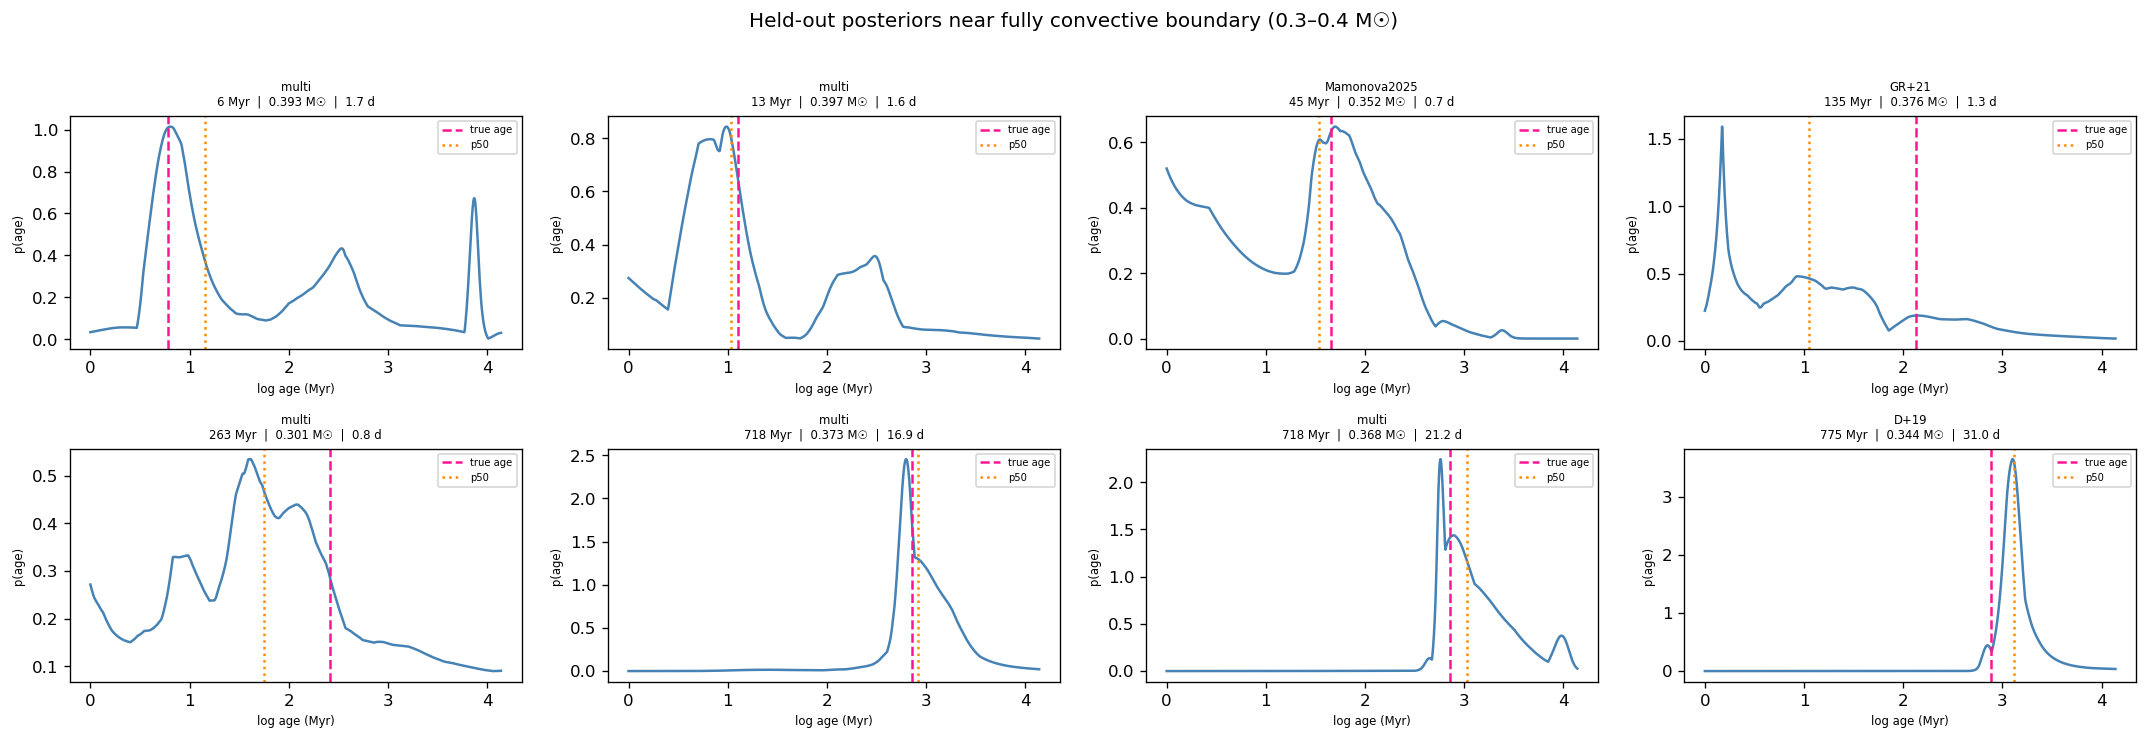

In [19]:
import matplotlib.pyplot as plt

_field = {'MOCADB', 'Engle2023', 'LWRD', 'Pass2022'}
fc_mask = (results_df['mass_msun'] >= 0.3) & (results_df['mass_msun'] <= 0.4)
fc_df   = results_df[fc_mask].copy().reset_index(drop=True)
fc_pos  = np.where(fc_mask)[0]

is_cluster = ~fc_df['source_paper'].isin(_field)
pool_idx   = np.where(is_cluster)[0] if is_cluster.sum() >= 8 else np.arange(len(fc_df))
age_order  = pool_idx[np.argsort(fc_df.iloc[pool_idx]['log_age_myr'].values)]
pick       = age_order[np.linspace(0, len(age_order) - 1, 8, dtype=int)]

n_cols = 4
n_rows = 2
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 6))
axes = axes.flatten()
for ax, i in zip(axes, pick):
    row      = fc_df.iloc[i]
    post_idx = fc_pos[i]
    ax.plot(LOGA_GRID, posteriors_kfold[post_idx], color='steelblue', lw=1.5)
    ax.axvline(row['log_age_myr'], color='deeppink', lw=1.5, ls='--', label='true age')
    ax.axvline(row['p50'], color='darkorange', lw=1.5, ls=':', label='p50')
    ax.set_title(f"{row['source_paper']}\n{10**row['log_age_myr']:.0f} Myr  |  {row['mass_msun']:.3f} M☉  |  {row['prot_days']:.1f} d", fontsize=7)
    ax.set_xlabel('log age (Myr)', fontsize=7)
    ax.set_ylabel('p(age)', fontsize=7)
    ax.legend(fontsize=6)
plt.suptitle('Held-out posteriors near fully convective boundary (0.3–0.4 M☉)', y=1.02)
plt.tight_layout()
plt.show()

## 7. P(P_rot | age, mass) heatmap per cluster

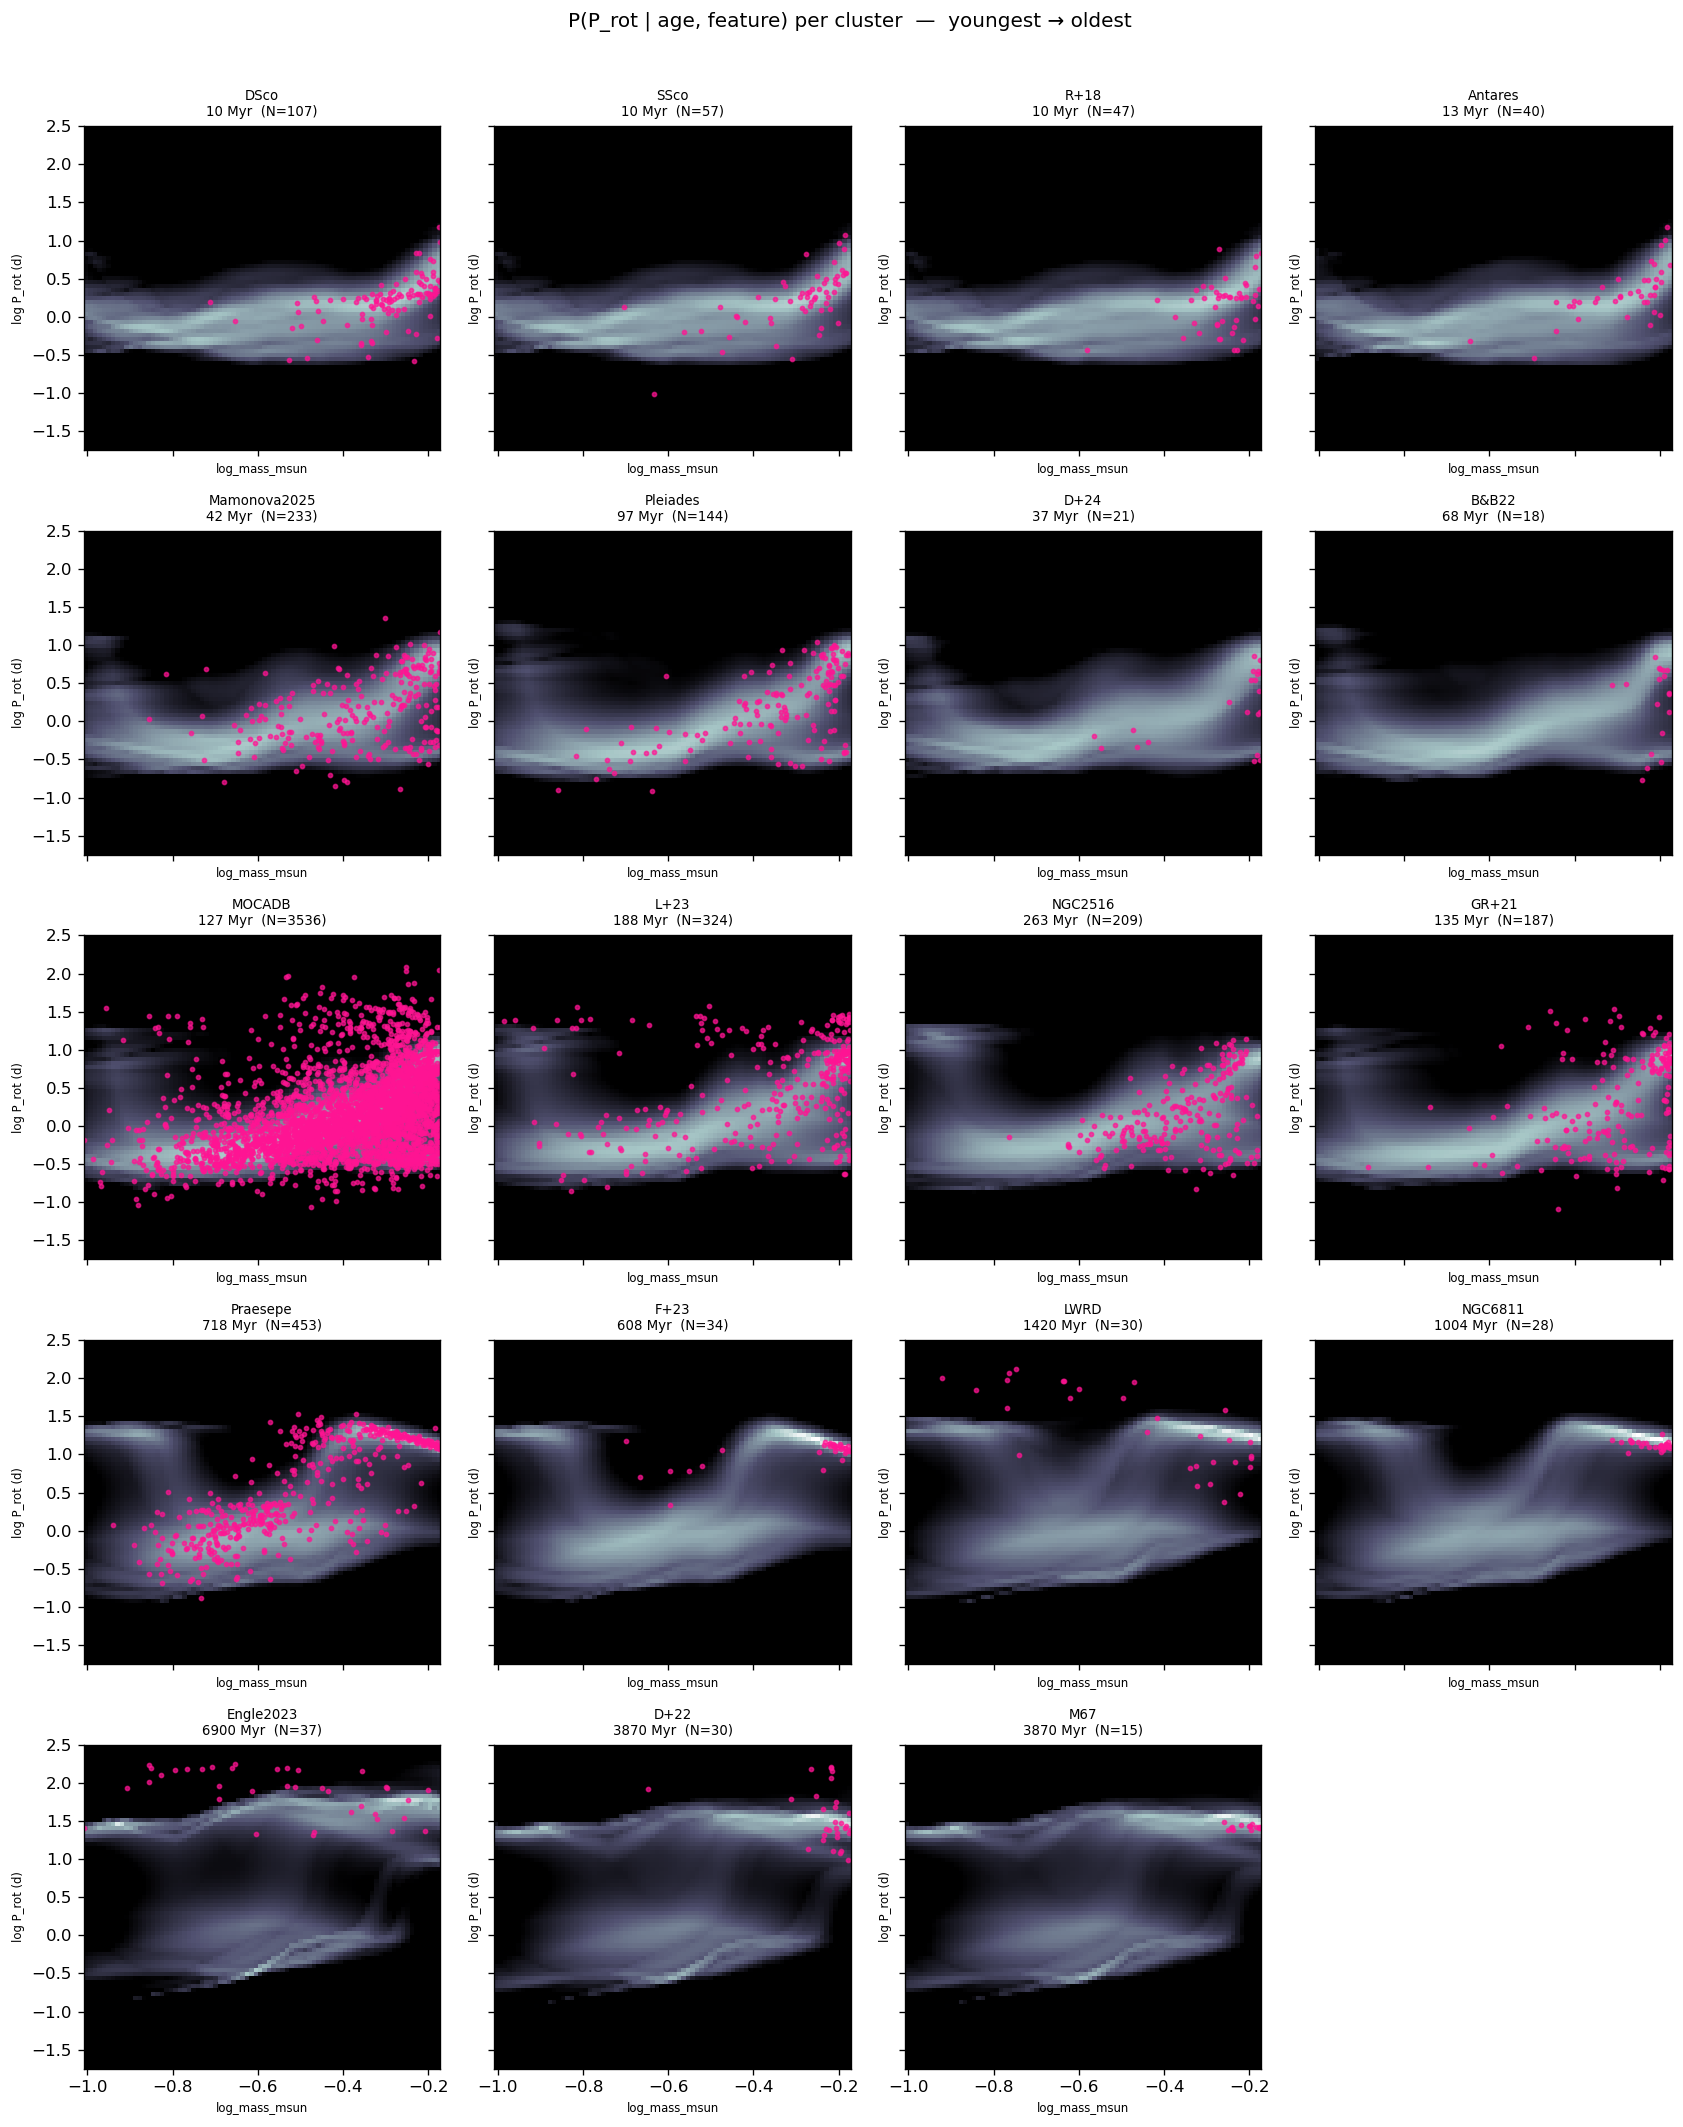

In [12]:
import importlib
import training.plots, training.report
importlib.reload(training.plots)
importlib.reload(training.report)
from training.report import prot_space_report  # rebind to new version

prot_space_report(fold_flows, df, COND_COLS, fold_scalers)

## 8. Summary statistics

In [10]:
print('=== 1A Mass — K-fold validation summary ===')
print(f'N stars evaluated : {len(results_df)}')
print(f'Median residual   : {results_df["residual_dex"].median():.3f} dex')
print(f'Median precision  : {(results_df["p84"] - results_df["p16"]).median():.3f} dex')
print(f'% within 0.3 dex  : {(results_df["residual_dex"].abs() < 0.3).mean()*100:.1f}%')
results_df.groupby('fold')[['residual_dex']].agg(['median', 'std'])

=== 1A Mass — K-fold validation summary ===
N stars evaluated : 5846
Median residual   : -0.214 dex
Median precision  : 1.625 dex
% within 0.3 dex  : 38.8%


residual_dex          
           median       std
fold                       
0       -0.211047  0.715169
1       -0.188383  0.717291
2       -0.203807  0.699249
3       -0.217085  0.726606
4       -0.232166  0.706085

## 9. Save models and results

In [11]:
import os
os.makedirs('../../outputs/1a_mass', exist_ok=True)

results_df.to_csv('../../outputs/1a_mass/results.csv', index=False)

for i, (flow, scaler) in enumerate(zip(fold_flows, fold_scalers)):
    torch.save(flow.state_dict(), f'../../outputs/1a_mass/fold{i}_flow.pt')
    with open(f'../../outputs/1a_mass/fold{i}_scaler.pkl', 'wb') as f:
        pickle.dump(scaler, f)

np.save('../../outputs/1a_mass/loss_curves.npy', np.array(loss_curves, dtype=object), allow_pickle=True)

print('Saved to outputs/1a_mass/')

Saved to outputs/1a_mass/
